## 1. Import Libraries

In [2]:
import os
import getpass
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings("ignore")

# LangChain - Document loading & splitting
from langchain_community.document_loaders import WebBaseLoader
from langchain_experimental.text_splitter import SemanticChunker

# LangChain - Embeddings & Vector Store
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
import chromadb

# LangChain - RAG chain
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough, RunnableParallel

# Ragas - Evaluation
from ragas import evaluate, EvaluationDataset
from ragas.dataset_schema import SingleTurnSample
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.metrics import (
    # Retrieval Metrics
    LLMContextRecall,
    LLMContextPrecisionWithReference,
    LLMContextPrecisionWithoutReference,
    ContextEntityRecall,
    NoiseSensitivity,
    # Generation Metrics
    Faithfulness,
    ResponseRelevancy,
    FactualCorrectness,
    SemanticSimilarity,
    # Robustness / Safety
    ResponseGroundedness,
)

## 2. API Key Setup

In [3]:
# Set OpenAI API key
if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

## 3. Document Loading

load documents from four URLs related to different topics to create a diverse knowledge base.

In [4]:
# Source URLs for the knowledge base
urls = [
    "https://en.wikipedia.org/wiki/Snow_leopard",
    "https://en.wikipedia.org/wiki/Gal%C3%A1pagos_Islands",
    "https://en.wikipedia.org/wiki/Penguin",
    "https://en.wikipedia.org/wiki/Amazon_rainforest",
]

loader = WebBaseLoader(urls)
docs = loader.load()

print(f"Loaded {len(docs)} documents.")
for i, doc in enumerate(docs):
    print(f"Doc {i+1}: {doc.metadata.get('source', 'unknown')} — {len(doc.page_content)} chars")

Loaded 4 documents.
Doc 1: https://en.wikipedia.org/wiki/Snow_leopard — 69471 chars
Doc 2: https://en.wikipedia.org/wiki/Gal%C3%A1pagos_Islands — 96691 chars
Doc 3: https://en.wikipedia.org/wiki/Penguin — 67360 chars
Doc 4: https://en.wikipedia.org/wiki/Amazon_rainforest — 85699 chars


## 4. clenaup of the docs

In [7]:
import re

def clean_text(text):
    # Remove multiple newlines
    text = re.sub(r'\n+', '\n', text)

    # Remove multiple spaces
    text = re.sub(r'\s+', ' ', text)

    # Remove citation markers like [1], [23]
    text = re.sub(r'\[\d+\]', '', text)

    # Strip start/end spaces
    return text.strip()

for doc in docs:
    doc.page_content = clean_text(doc.page_content)

docs = [d for d in docs if len(d.page_content) > 200]

## 5. Document Chunking

We use **SemanticChunker** from `langchain_experimental`, which groups sentences into chunks based on semantic similarity — producing more coherent retrieval units compared to naive character splitting.

In [9]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

semantic_splitter = SemanticChunker(
    embeddings,
    breakpoint_threshold_type="percentile",
    breakpoint_threshold_amount=90,
)

chunks = semantic_splitter.split_documents(docs)

print(f"Created {len(chunks)} semantic chunks.")
print(f"Average chunk length: {sum(len(c.page_content) for c in chunks)//len(chunks)} chars")

Created 450 semantic chunks.
Average chunk length: 694 chars


## 6. Vector Store (ChromaDB)

Store the semantically-chunked documents as embeddings in a local ChromaDB instance.

In [10]:
import shutil
from langchain_chroma import Chroma

persist_dir = "./chroma_db_eval"

# Remove existing DB
if os.path.exists(persist_dir):
    shutil.rmtree(persist_dir)

# Create Chroma client
client = chromadb.PersistentClient(path=persist_dir)

# Create collection
collection = client.create_collection(name="docs")

# Prepare data
texts = [doc.page_content for doc in chunks]
metadatas = [doc.metadata for doc in chunks]

# Generate embeddings
embeddings_list = embeddings.embed_documents(texts)

# Add to collection
collection.add(
    documents=texts,
    metadatas=metadatas,
    embeddings=embeddings_list,
    ids=[str(i) for i in range(len(texts))]
)

# Wrap with LangChain
vectorstore = Chroma(
    client=client,
    collection_name="docs",
    embedding_function=embeddings
)

# Create retriever
retriever = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={"k": 4, "fetch_k": 10}
)

print(f" Vector store created with {collection.count()} embeddings.")

 Vector store created with 450 embeddings.


## 7. RAG Chain Setup

Build the full RAG chain using **GPT-4o** and a structured prompt. We also capture the retrieved contexts for evaluation.

In [11]:
# LLM: GPT-4o (latest, cost-effective for evaluation)
llm = ChatOpenAI(
    model="gpt-4o",
    temperature=0,        # Deterministic output for evaluation
    max_tokens=1024,
)

# RAG prompt template
RAG_PROMPT = """\
You are an expert assistant. Use the following context to answer the question accurately and concisely.
If the answer is not in the context, say: "I don't have enough information to answer this."
Do NOT make up information.

Context:
{context}

Question: {question}

Answer:"""

prompt = ChatPromptTemplate.from_template(RAG_PROMPT)

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# Chain that also returns the source documents
rag_chain_with_context = RunnableParallel(
    context=retriever | format_docs,
    question=RunnablePassthrough(),
)

# Full chain for answer generation
rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

print("RAG chain ready. Model: gpt-4o | Retriever: MMR (k=4)")

RAG chain ready. Model: gpt-4o | Retriever: MMR (k=4)


## 8. Evaluation Queries & Ground Truths

Define queries covering all four knowledge base topics along with their ground-truth answers.

In [12]:
questions = [
    # Snow Leopard
    "In which countries are snow leopards found?",
    "What are the main threats to snow leopard populations?",
    # Galápagos Islands
    "Who discovered the Galápagos Islands and how?",
    "What is the significance of the Galápagos Islands for evolutionary biology?",
    # Penguins
    "What are the major threats to penguin populations?",
    "Where do penguins primarily live and what do they eat?",
    # Amazon Rainforest
    "Why is the Amazon rainforest important for the global climate?",
    "What is the main cause of Amazon deforestation?",
]

ground_truths = [
    # Snow Leopard
    "Snow leopards are found across 12 countries in Central and South Asia, including Afghanistan, Bhutan, China, India, Kazakhstan, Kyrgyzstan, Mongolia, Nepal, Pakistan, Russia, Tajikistan, and Uzbekistan.",
    "The main threats to snow leopards include poaching for their fur and bones, retaliatory killing by herders whose livestock they prey on, habitat loss, and climate change reducing their alpine habitat.",
    # Galápagos Islands
    "The Galápagos Islands were discovered by Tomás de Berlanga, the Bishop of Panamá, in 1535 when his ship drifted off course while sailing to Peru.",
    "The Galápagos Islands are crucial for evolutionary biology because they inspired Charles Darwin's theory of natural selection during his 1835 visit, with the unique species found there demonstrating adaptive radiation.",
    # Penguins
    "Major threats to penguins include climate change, overfishing reducing their food supply, oil spills, habitat destruction, and introduced predators such as rats and cats on nesting islands.",
    "Penguins primarily live in the Southern Hemisphere, particularly Antarctica, South America, South Africa, and New Zealand. They eat fish, squid, and krill.",
    # Amazon Rainforest
    "The Amazon rainforest regulates global climate by absorbing vast amounts of CO2, producing around 20% of the world's oxygen, influencing rainfall patterns, and housing immense biodiversity.",
    "The main cause of Amazon deforestation is agricultural expansion, especially cattle ranching and soy farming, alongside logging, mining, and infrastructure development.",
]

print(f" Prepared {len(questions)} evaluation queries with ground truths.")

 Prepared 8 evaluation queries with ground truths.


## 9. Generate Answers & Retrieve Contexts

In [13]:
answers = []
contexts = []

for i, question in enumerate(questions):
    print(f"[{i+1}/{len(questions)}] Processing: {question[:60]}...")

    # Retrieve relevant context chunks
    retrieved_docs = retriever.invoke(question)
    context_list = [doc.page_content for doc in retrieved_docs]

    # Generate answer
    answer = rag_chain.invoke(question)

    answers.append(answer)
    contexts.append(context_list)

print("\n All answers generated.")
print(f"\n--- Example: Q1 ---")
print(f"Q: {questions[0]}")
print(f"A: {answers[0]}")

[1/8] Processing: In which countries are snow leopards found?...
[2/8] Processing: What are the main threats to snow leopard populations?...
[3/8] Processing: Who discovered the Galápagos Islands and how?...
[4/8] Processing: What is the significance of the Galápagos Islands for evolut...
[5/8] Processing: What are the major threats to penguin populations?...
[6/8] Processing: Where do penguins primarily live and what do they eat?...
[7/8] Processing: Why is the Amazon rainforest important for the global climat...
[8/8] Processing: What is the main cause of Amazon deforestation?...

 All answers generated.

--- Example: Q1 ---
Q: In which countries are snow leopards found?
A: Snow leopards are found in Afghanistan, Bhutan, China, India, Kazakhstan, Kyrgyzstan, Mongolia, Nepal, Pakistan, Russia, Tajikistan, and Uzbekistan.


## 10. Build Ragas Evaluation Dataset

Construct a `EvaluationDataset` using the new Ragas `SingleTurnSample` schema.

In [ ]:
# Build list of SingleTurnSample objects (new Ragas API)
samples = [
    SingleTurnSample(
        user_input=question,
        response=answer,
        reference=ground_truth,
        retrieved_contexts=context_list,
    )
    for question, answer, ground_truth, context_list
    in zip(questions, answers, ground_truths, contexts)
]

evaluation_dataset = EvaluationDataset(samples=samples)

print(f"Evaluation dataset ready: {len(evaluation_dataset.samples)} samples.")
print(f"Fields per sample: user_input, response, reference, retrieved_contexts")

 Evaluation dataset ready: 8 samples.
   Fields per sample: user_input, response, reference, retrieved_contexts


## 11. Configure Ragas LLM & Embeddings Wrappers

In [15]:
# Evaluator LLM: GPT-4o-mini is cheaper for running many metric calculations
evaluator_llm = LangchainLLMWrapper(
    ChatOpenAI(model="gpt-4o-mini", temperature=0)
)

# Evaluator Embeddings: for SemanticSimilarity & ResponseRelevancy
evaluator_embeddings = LangchainEmbeddingsWrapper(
    OpenAIEmbeddings(model="text-embedding-3-small")
)

print(" Ragas evaluator LLM and embeddings configured.")
print("   LLM: gpt-4o-mini | Embeddings: text-embedding-3-small")

 Ragas evaluator LLM and embeddings configured.
   LLM: gpt-4o-mini | Embeddings: text-embedding-3-small


# RAG Evaluation Metrics — Detailed Reference

A breakdown of all 10 metrics used to evaluate a RAG pipeline, grouped by category.

---

## Retrieval Metrics

These evaluate whether the **retriever** is pulling the right chunks — before the LLM even sees them. A bad retriever cannot be fixed by a better prompt.

---

### 1. `LLMContextRecall`

**Question it answers:** Of all the facts in the ground-truth answer, how many were actually present in the retrieved context?

**How it works:**
1. An LLM decomposes the ground-truth answer into individual atomic claims (e.g. "The boiling point of water is 100°C").
2. Each claim is checked against the retrieved chunks — was it retrievable?
3. Score = claims found in context / total claims.

**Score range:** 0.0 → 1.0 (higher is better)

**What a low score means:** Your retriever is fundamentally missing information. The answer literally cannot be constructed from what was retrieved. No amount of prompt engineering fixes this — you need better chunking, embedding, or retrieval strategy.

**What a high score means:** Everything the answer needs is present somewhere in the retrieved context.

---

### 2. `LLMContextPrecisionWithReference`

**Question it answers:** Are the most relevant chunks ranked highest in the retrieved list?

**How it works:** Uses a reference answer to judge which retrieved chunks are actually relevant, then checks whether those relevant chunks appear near the top of the ranked list. Penalizes when irrelevant chunks are ranked above relevant ones.

**Score range:** 0.0 → 1.0 (higher is better)

**Why ranking matters:** Most RAG pipelines pass only the top-k chunks to the LLM. If the most relevant chunk is ranked 8th and you're only passing top-3, you lose it entirely. High recall with poor precision wastes the context window.

**What a low score means:** Your re-ranker or similarity function is ordering chunks poorly. Consider adding a cross-encoder re-ranker on top of your vector search.

---

### 3. `LLMContextPrecisionWithoutReference`

**Question it answers:** Same as above, but without needing a reference answer.

**How it works:** Instead of using a ground-truth answer to judge relevance, the LLM itself assesses whether each retrieved chunk is relevant to the question. Useful when you don't have ground-truth answers for every test case.

**Score range:** 0.0 → 1.0 (higher is better)

**Trade-off vs. WithReference:** Less accurate (the LLM's judgment of relevance may differ from the ground truth) but far cheaper to run at scale since you don't need annotated answers.

**When to use:** Early-stage evaluation when you only have questions, not question-answer pairs.

---

### 4. `ContextEntityRecall`

**Question it answers:** Are the named entities from the ground-truth answer present in the retrieved context?

**How it works:**
1. Named entities (people, places, organizations, dates, values) are extracted from the ground-truth answer.
2. The same entity extraction is run on the retrieved chunks.
3. Score = entities found in context / total entities in ground truth.

**Score range:** 0.0 → 1.0 (higher is better)

**Why it's useful:** Entity-level recall is a stricter, more interpretable signal than semantic similarity. If the answer mentions "Dr. Sarah Chen, 2019, Stanford" and none of those appear in the context, the retriever has clearly failed — regardless of how semantically close the chunks are.

**What a low score means:** The retriever is returning thematically related but factually incorrect chunks. Common when chunks are too large and dilute specific entity mentions.

---

### 5. `NoiseSensitivity`

**Question it answers:** How much does irrelevant context hurt the answer quality?

**How it works:** Compares answer quality when the LLM is given only relevant chunks vs. when irrelevant ("noisy") chunks are mixed in. The delta between the two scores is the sensitivity measure.

**Score range:** 0.0 → 1.0 (lower is better — lower means less sensitive to noise)

**Why it matters:** In real pipelines, retrieved context is never perfectly clean. A robust system should produce good answers even when 2-3 of the top-5 chunks are off-topic. High noise sensitivity means the LLM is easily confused or distracted by irrelevant content.

**What a high score means:** Your LLM or prompt is not robust to retrieval noise. Consider adding a filtering step, or use a system prompt that instructs the model to ignore irrelevant context explicitly.

---

## Generation Metrics

These evaluate the **LLM's output** given whatever context was retrieved. They assume retrieval has already happened and focus purely on answer quality.

---

### 6. `Faithfulness`

**Question it answers:** Does the answer rely only on what's in the retrieved context, or does the LLM hallucinate?

**How it works:**
1. The answer is decomposed into individual claims.
2. Each claim is verified against the retrieved context — can it be directly supported?
3. Score = claims supported by context / total claims.

**Score range:** 0.0 → 1.0 (higher is better)

**What a low score means:** The LLM is adding information not present in the context — hallucinating facts, inferring too aggressively, or using parametric knowledge instead of the retrieved content. This is the most critical generation metric for factual RAG systems.

**Common causes of low faithfulness:** Insufficient context (LLM fills gaps), overly creative temperature setting, or a model that prioritizes fluency over groundedness.

---

### 7. `ResponseRelevancy`

**Question it answers:** Is the answer actually addressing the question asked?

**How it works:** An LLM generates several hypothetical questions that the given answer could plausibly answer. The embedding similarity between those generated questions and the original question is computed. High similarity = the answer is on-topic.

**Score range:** 0.0 → 1.0 (higher is better)

**What a low score means:** The answer is technically correct but doesn't address what was asked — it's tangential, over-broad, or answers a slightly different question. Common when retrieved context is loosely related but not precisely on-topic.

**Note:** This metric does not check factual correctness — a confidently wrong answer can still score high on relevancy.

---

### 8. `FactualCorrectness`

**Question it answers:** Is the answer factually correct compared to the ground-truth answer?

**How it works:** Compares the generated answer against the reference answer using claim-level matching — similar to precision/recall but for facts. Distinguishes between claims that are correct, incorrect, or missing.

**Score range:** 0.0 → 1.0 (higher is better)

**What it catches:** Unlike faithfulness (which only checks against retrieved context), this checks against the actual ground truth. An answer can be faithful to bad context but still be factually wrong. This metric catches that.

**What a low score means:** Either the retriever returned wrong information and the LLM faithfully reproduced it, or the LLM introduced errors of its own.

---

### 9. `SemanticSimilarity`

**Question it answers:** How semantically close is the generated answer to the ground-truth answer?

**How it works:** Embeds both the generated answer and the ground-truth answer, then computes cosine similarity between the two vectors.

**Score range:** -1.0 → 1.0 (higher is better; typically 0.7–1.0 in practice)

**What it captures:** Overall semantic alignment without requiring word-for-word matching. A paraphrased but correct answer should score high.

**Limitations:** Can give high scores to answers that are semantically similar but factually wrong (e.g. "The reaction occurs at high temperatures" vs "The reaction occurs at low temperatures" — semantically similar, opposite meaning). Best used alongside `FactualCorrectness`, not as a standalone metric.

---

### 10. `ResponseGroundedness`

**Question it answers:** Is every claim in the answer grounded in the retrieved context?

**How it works:** Similar to `Faithfulness` but typically stricter — checks not just whether claims can be supported, but whether each sentence or clause directly traces back to a specific passage in the context. Some implementations also check whether the LLM cited the right source.

**Score range:** 0.0 → 1.0 (higher is better)

**Faithfulness vs. Groundedness:** Faithfulness asks "can this claim be found in context?" Groundedness asks "is this claim *directly derived* from context with a clear trace?" Groundedness is stricter and more useful for compliance or citation-heavy use cases.

**What a low score means:** The LLM is paraphrasing beyond what the context supports, combining facts across chunks in ways that aren't explicitly stated, or drawing inferences that aren't grounded.

---

## Quick Reference Summary

| Metric | Evaluates | Needs Ground Truth? | Lower is Better? |
|---|---|---|---|
| `LLMContextRecall` | Retriever coverage | Yes | No |
| `LLMContextPrecisionWithReference` | Retriever ranking | Yes | No |
| `LLMContextPrecisionWithoutReference` | Retriever ranking | No | No |
| `ContextEntityRecall` | Entity-level retrieval | Yes | No |
| `NoiseSensitivity` | Robustness to bad chunks | Yes | Yes |
| `Faithfulness` | Hallucination | No | No |
| `ResponseRelevancy` | Answer on-topic-ness | No | No |
| `FactualCorrectness` | Answer accuracy | Yes | No |
| `SemanticSimilarity` | Answer closeness | Yes | No |
| `ResponseGroundedness` | Claim traceability | No | No |

---

## Which Metrics Matter Most?

**For a factual Q&A system:** prioritize `Faithfulness`, `FactualCorrectness`, and `LLMContextRecall`.

**For a search/discovery system:** prioritize `LLMContextPrecisionWithReference` and `ResponseRelevancy`.

**For compliance or citation-heavy use cases:** prioritize `ResponseGroundedness` and `Faithfulness`.

**For diagnosing retrieval vs. generation failures:** run `LLMContextRecall` first. If it's high but `FactualCorrectness` is low, the problem is in generation. If `LLMContextRecall` is low, fix retrieval first before touching the LLM.

In [16]:
# ── Retrieval Metrics ──────────────────────────────────────────────────────────

context_recall = LLMContextRecall(llm=evaluator_llm)

context_precision_with_ref = LLMContextPrecisionWithReference(llm=evaluator_llm)

context_precision_no_ref = LLMContextPrecisionWithoutReference(llm=evaluator_llm)

context_entity_recall = ContextEntityRecall(llm=evaluator_llm)

noise_sensitivity = NoiseSensitivity(llm=evaluator_llm)

# ── Generation Metrics ────────────────────────────────────────────────────────

faithfulness = Faithfulness(llm=evaluator_llm)

response_relevancy = ResponseRelevancy(
    llm=evaluator_llm,
    embeddings=evaluator_embeddings,
)

factual_correctness = FactualCorrectness(llm=evaluator_llm)

semantic_similarity = SemanticSimilarity(embeddings=evaluator_embeddings)

response_groundedness = ResponseGroundedness(llm=evaluator_llm)

# ── Full Metrics List ─────────────────────────────────────────────────────────
metrics = [
    context_recall,
    context_precision_with_ref,
    context_precision_no_ref,
    context_entity_recall,
    noise_sensitivity,
    faithfulness,
    response_relevancy,
    factual_correctness,
    semantic_similarity,
    response_groundedness,
]

print(f" {len(metrics)} evaluation metrics configured.")

 10 evaluation metrics configured.


## 13. Run Ragas Evaluation

In [17]:
print("Running Ragas evaluation... (this may take a few minutes)")

results = evaluate(
    dataset=evaluation_dataset,
    metrics=metrics,
)

print("\n Evaluation complete!")

Running Ragas evaluation... (this may take a few minutes)


Evaluating:  40%|████      | 32/80 [02:59<04:17,  5.37s/it]Exception raised in Job[14]: TimeoutError()
Exception raised in Job[4]: TimeoutError()
Evaluating: 100%|██████████| 80/80 [07:11<00:00,  5.39s/it]



 Evaluation complete!


## 14. Per-Query Results Table

In [18]:
results_df = results.to_pandas()

# Add a short question label for readability
results_df.insert(0, "question_short", [q[:50] + "..." for q in questions])

# Round numeric columns
numeric_cols = results_df.select_dtypes(include="number").columns
results_df[numeric_cols] = results_df[numeric_cols].round(4)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

print("Per-query evaluation scores:")
results_df

Per-query evaluation scores:


,question_short,user_input,retrieved_contexts,response,reference,context_recall,llm_context_precision_with_reference,llm_context_precision_without_reference,context_entity_recall,noise_sensitivity(mode=relevant),faithfulness,answer_relevancy,factual_correctness(mode=f1),semantic_similarity,nv_response_groundedness
0,In which countries are snow leopards found?...,In which countries are snow leopards found?,[It is listed in CITES Appendix I and legally ...,"Snow leopards are found in Afghanistan, Bhutan...",Snow leopards are found across 12 countries in...,1.0,1.0000,1.0,0.5625,NaN,1.0,0.9806,1.0,0.9361,1.0
1,What are the main threats to snow leopard popu...,What are the main threats to snow leopard popu...,[It is listed in CITES Appendix I and legally ...,I don't have enough information to answer this.,The main threats to snow leopards include poac...,1.0,1.0000,0.0,0.0000,NaN,0.0,0.0000,0.0,0.0732,0.0
2,Who discovered the Galápagos Islands and how?...,Who discovered the Galápagos Islands and how?,[Bibliography[edit] This article incorporates ...,I don't have enough information to answer this.,The Galápagos Islands were discovered by Tomás...,0.0,0.0000,0.0,0.0000,NaN,0.0,0.0000,0.0,0.0019,0.0
3,What is the significance of the Galápagos Isla...,What is the significance of the Galápagos Isla...,[The islands' biodiversity is under threat fro...,I don't have enough information to answer this.,The Galápagos Islands are crucial for evolutio...,1.0,0.0000,0.0,0.2000,NaN,0.0,0.0000,0.0,0.0339,0.0
4,What are the major threats to penguin populati...,What are the major threats to penguin populati...,[Humerus 2). Sesamoid Bone 3). Radius 4). Ulna...,I don't have enough information to answer this.,Major threats to penguins include climate chan...,1.0,0.3333,0.0,0.0000,NaN,0.0,0.0000,0.0,0.0296,0.0
5,Where do penguins primarily live and what do t...,Where do penguins primarily live and what do t...,[Humerus 2). Sesamoid Bone 3). Radius 4). Ulna...,I don't have enough information to answer this.,Penguins primarily live in the Southern Hemisp...,0.5,1.0000,0.0,0.1111,NaN,0.5,0.0000,0.0,0.0041,0.0
6,Why is the Amazon rainforest important for the...,Why is the Amazon rainforest important for the...,"[Retrieved November 5, 2020. ^ Melillo, J.M.; ...",I don't have enough information to answer this.,The Amazon rainforest regulates global climate...,1.0,0.5000,0.0,0.2500,0.0,0.0,0.0000,0.0,0.0478,0.0
7,What is the main cause of Amazon deforestation...,What is the main cause of Amazon deforestation?,[Amazon rainforest - Wikipedia Jump to content...,I don't have enough information to answer this.,The main cause of Amazon deforestation is agri...,1.0,1.0000,0.0,0.0000,0.0,0.0,0.0000,0.0,0.0758,0.0


## 15. Aggregate Scores (Mean Across All Queries)

In [19]:
metric_cols = [c for c in results_df.columns if c not in ["user_input", "response", "retrieved_contexts", "reference", "question_short"]]

agg_scores = results_df[metric_cols].mean().sort_values(ascending=False)

print("=" * 55)
print(f"{'METRIC':<40} {'SCORE':>8}")
print("=" * 55)
for metric, score in agg_scores.items():
    bar = "█" * int(score * 20)
    status = "🟢" if score >= 0.8 else "🟡" if score >= 0.6 else "🔴"
    print(f"{status} {metric:<38} {score:>8.4f}  {bar}")
print("=" * 55)

METRIC                                      SCORE
🟢 context_recall                           0.8125  ████████████████
🟡 llm_context_precision_with_reference     0.6042  ████████████
🔴 faithfulness                             0.1875  ███
🔴 semantic_similarity                      0.1503  ███
🔴 context_entity_recall                    0.1404  ██
🔴 llm_context_precision_without_reference   0.1250  ██
🔴 factual_correctness(mode=f1)             0.1250  ██
🔴 nv_response_groundedness                 0.1250  ██
🔴 answer_relevancy                         0.1226  ██
🔴 noise_sensitivity(mode=relevant)         0.0000  


## 16. Visualize Results

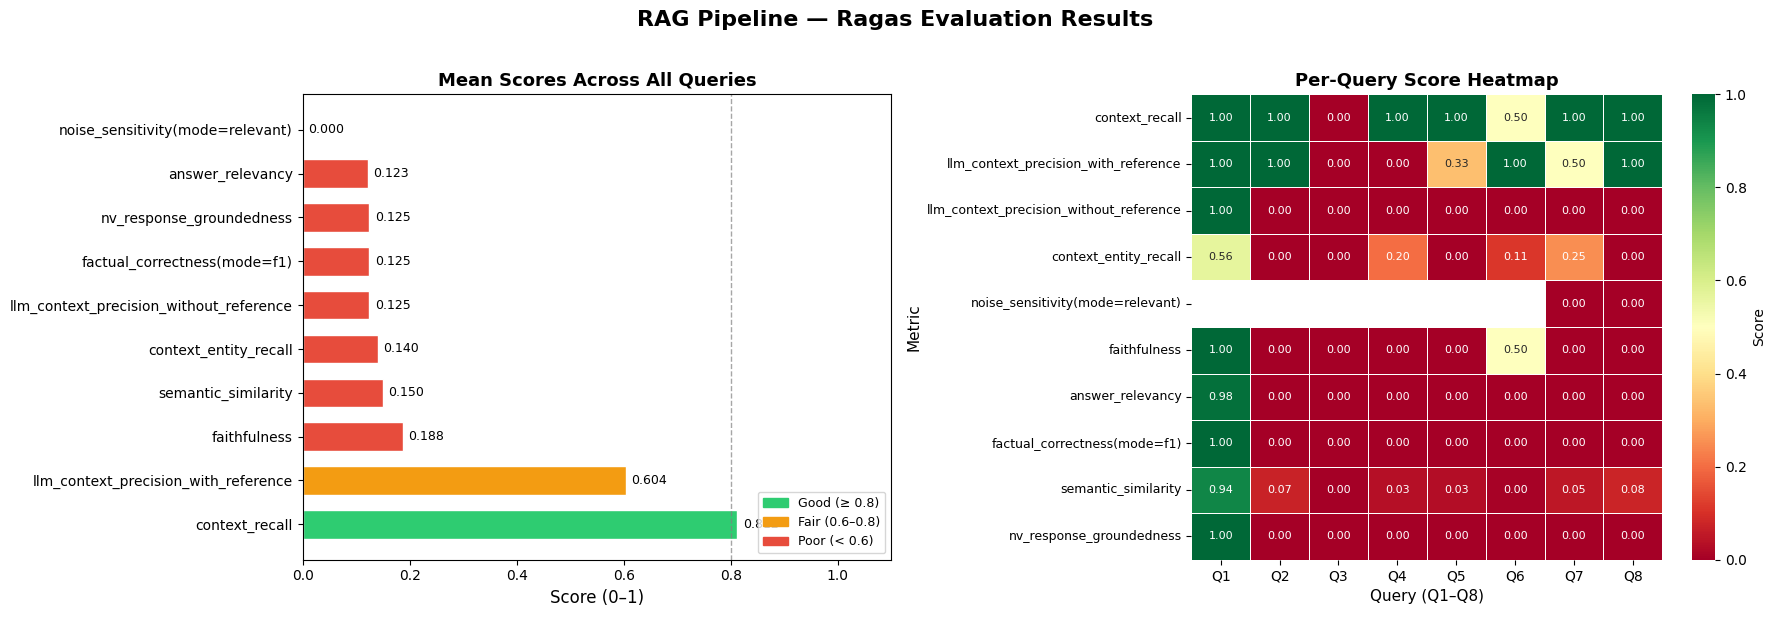

 Plot saved: ragas_evaluation_results.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("RAG Pipeline — Ragas Evaluation Results", fontsize=16, fontweight="bold", y=1.02)

# ── Plot 1: Aggregate scores bar chart ───────────────────────────────────────
colors = ["#2ecc71" if s >= 0.8 else "#f39c12" if s >= 0.6 else "#e74c3c" for s in agg_scores.values]
bars = axes[0].barh(agg_scores.index, agg_scores.values, color=colors, edgecolor="white", height=0.65)
axes[0].set_xlim(0, 1.1)
axes[0].set_xlabel("Score (0–1)", fontsize=12)
axes[0].set_title("Mean Scores Across All Queries", fontsize=13, fontweight="bold")
axes[0].axvline(0.8, color="gray", linestyle="--", linewidth=1, alpha=0.7, label="Target: 0.8")
axes[0].legend(fontsize=10)
for bar, val in zip(bars, agg_scores.values):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height() / 2, f"{val:.3f}",
                 va="center", ha="left", fontsize=9)

green_patch  = mpatches.Patch(color="#2ecc71", label="Good (≥ 0.8)")
yellow_patch = mpatches.Patch(color="#f39c12", label="Fair (0.6–0.8)")
red_patch    = mpatches.Patch(color="#e74c3c", label="Poor (< 0.6)")
axes[0].legend(handles=[green_patch, yellow_patch, red_patch], loc="lower right", fontsize=9)

# ── Plot 2: Heatmap of per-query scores ──────────────────────────────────────
heatmap_df = results_df[metric_cols].copy()
heatmap_df.index = [f"Q{i+1}" for i in range(len(heatmap_df))]

sns.heatmap(
    heatmap_df.T,
    ax=axes[1],
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Score"},
    annot_kws={"size": 8},
)
axes[1].set_title("Per-Query Score Heatmap", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Query (Q1–Q8)", fontsize=11)
axes[1].set_ylabel("Metric", fontsize=11)
axes[1].tick_params(axis="y", labelsize=9)

plt.tight_layout()
plt.savefig("ragas_evaluation_results.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Plot saved: ragas_evaluation_results.png")

## 17. Radar Chart — Retrieval vs Generation

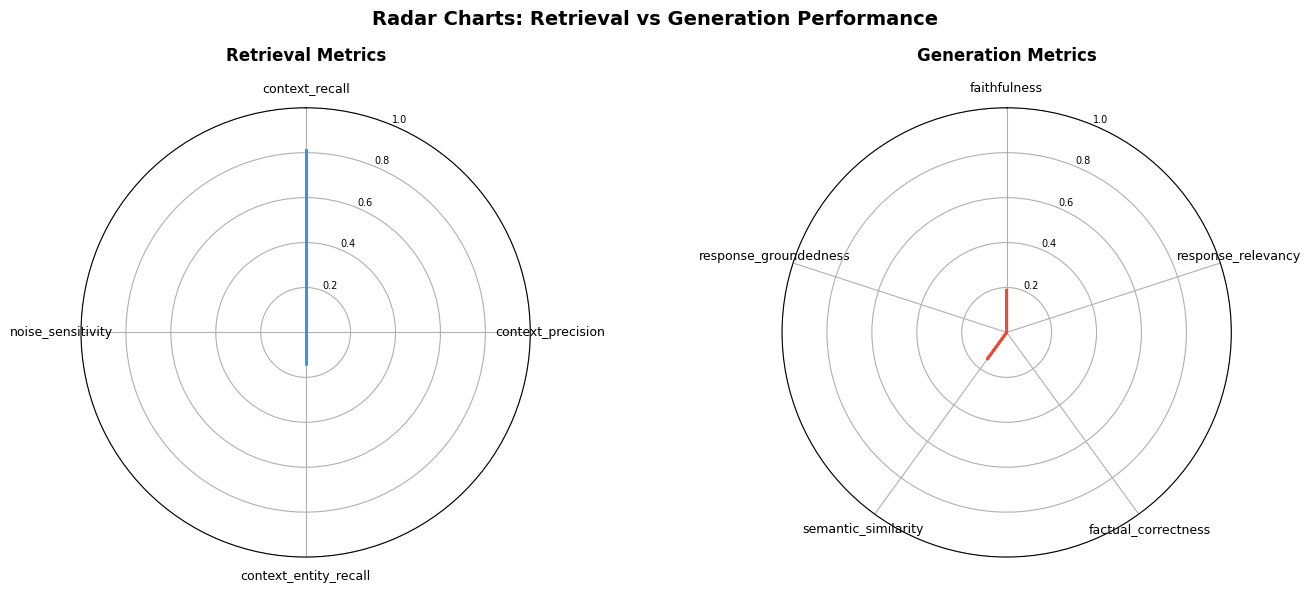

 Radar chart saved: ragas_radar_chart.png


In [21]:
import numpy as np

retrieval_metrics = ["context_recall", "context_precision", "context_entity_recall", "noise_sensitivity"]
generation_metrics = ["faithfulness", "response_relevancy", "factual_correctness", "semantic_similarity", "response_groundedness"]

retrieval_scores  = [agg_scores.get(m, 0) for m in retrieval_metrics]
generation_scores = [agg_scores.get(m, 0) for m in generation_metrics]

def radar_chart(ax, categories, values, color, title):
    N = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    values_plot = values + [values[0]]
    angles += angles[:1]
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=9)
    ax.set_ylim(0, 1)
    ax.plot(angles, values_plot, color=color, linewidth=2)
    ax.fill(angles, values_plot, color=color, alpha=0.25)
    ax.set_title(title, pad=15, fontsize=12, fontweight="bold")
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=7)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), subplot_kw=dict(polar=True))
fig.suptitle("Radar Charts: Retrieval vs Generation Performance", fontsize=14, fontweight="bold")

radar_chart(ax1, retrieval_metrics,  retrieval_scores,  "#3498db", "Retrieval Metrics")
radar_chart(ax2, generation_metrics, generation_scores, "#e74c3c", "Generation Metrics")

plt.tight_layout()
plt.savefig("ragas_radar_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Radar chart saved: ragas_radar_chart.png")

## 19. Interpretation & Recommendations

Use the following framework to interpret your Ragas scores:

| Score Range | Meaning | Action |
|-------------|---------|--------|
| **0.8 – 1.0** | 🟢 Strong | Maintain current config |
| **0.6 – 0.8** | 🟡 Fair | Tune the relevant component |
| **0.0 – 0.6** | 🔴 Weak | Needs significant improvement |

### What to do if scores are low:

- **Low `context_recall`** → Add more relevant documents; increase retrieval `k`
- **Low `context_precision`** → Use smaller, more targeted chunks; try re-ranking
- **Low `context_entity_recall`** → Improve document coverage; add entity-rich sources
- **High `noise_sensitivity`** → Use stricter similarity threshold in retrieval
- **Low `faithfulness`** → Tighten the system prompt; instruct model to avoid hallucination
- **Low `response_relevancy`** → Improve question handling in prompt template
- **Low `factual_correctness`** → Improve document quality; use a stronger LLM
- **Low `semantic_similarity`** → Provide better ground-truth references; refine prompts
- **Low `response_groundedness`** → Add explicit instruction not to use prior knowledge

In [22]:
# Final summary printout
print("\n" + "═" * 55)
print("   RAGAS EVALUATION SUMMARY")
print("═" * 55)

retrieval_avg  = agg_scores[[m for m in retrieval_metrics  if m in agg_scores]].mean()
generation_avg = agg_scores[[m for m in generation_metrics if m in agg_scores]].mean()
overall_avg    = agg_scores.mean()

def grade(score):
    return "🟢 STRONG" if score >= 0.8 else "🟡 FAIR" if score >= 0.6 else "🔴 WEAK"

print(f"  Retrieval  avg score:  {retrieval_avg:.4f}  {grade(retrieval_avg)}")
print(f"  Generation avg score:  {generation_avg:.4f}  {grade(generation_avg)}")
print(f"  Overall    avg score:  {overall_avg:.4f}  {grade(overall_avg)}")
print("═" * 55)


═══════════════════════════════════════════════════════
   RAGAS EVALUATION SUMMARY
═══════════════════════════════════════════════════════
  Retrieval  avg score:  0.4765  🔴 WEAK
  Generation avg score:  0.1689  🔴 WEAK
  Overall    avg score:  0.2392  🔴 WEAK
═══════════════════════════════════════════════════════
